In [1]:
import numpy as np
import matplotlib.pyplot as plt

FashionMNIST

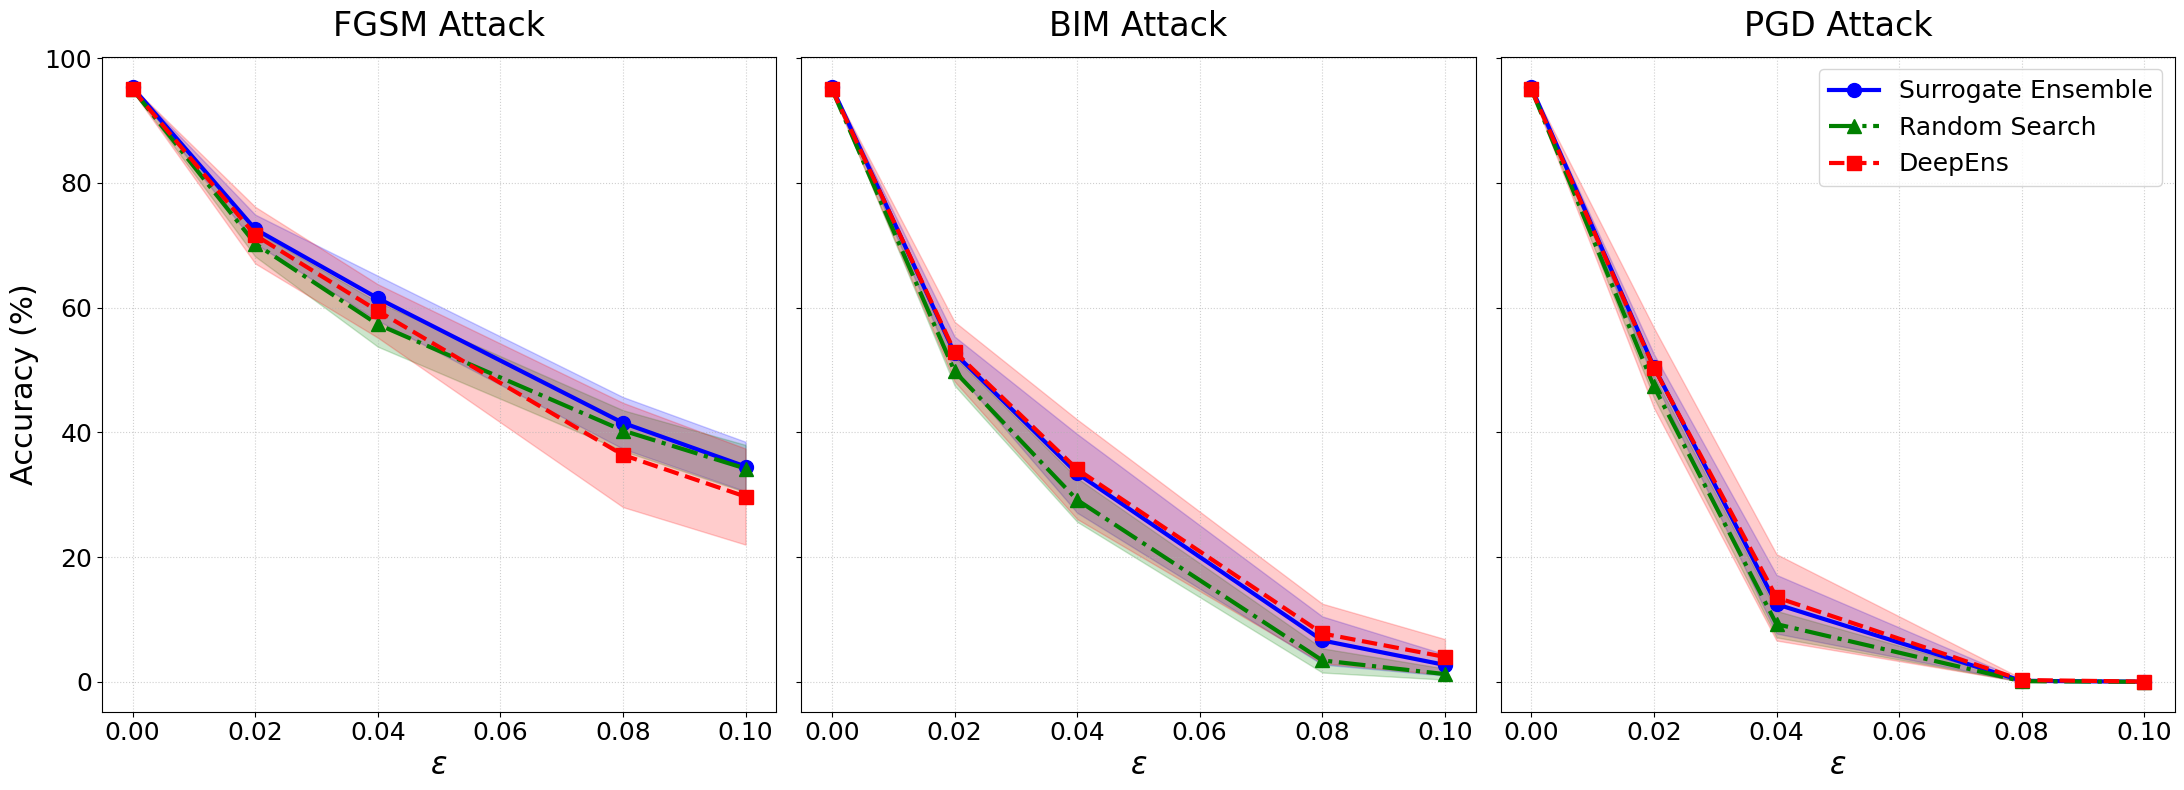

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# =======================
# Epsilon grid (shared)
# =======================
eps = np.array([0.00, 0.02, 0.04, 0.08, 0.10])

# =======================
# Surrogate Ensemble
# =======================
fgsm_sur_mean = np.array([95.29, 72.59, 61.51, 41.52, 34.52])
fgsm_sur_std  = np.array([0.10, 2.32, 3.60, 4.14, 3.97])

bim_sur_mean = np.array([95.31, 52.69, 33.43, 6.64, 2.72])
bim_sur_std  = np.array([0.12, 2.68, 6.31, 3.85, 1.71])

pgd_sur_mean = np.array([95.31, 50.50, 12.45, 0.17, 0.03])
pgd_sur_std  = np.array([0.12, 2.05, 4.70, 0.14, 0.04])

# =======================
# Random Search
# =======================
fgsm_rs_mean = np.array([95.01, 70.25, 57.31, 40.29, 34.20])
fgsm_rs_std  = np.array([0.19, 2.05, 3.57, 3.26, 3.79])

bim_rs_mean = np.array([95.02, 49.80, 29.17, 3.44, 1.25])
bim_rs_std  = np.array([0.18, 2.28, 3.50, 1.94, 0.89])

pgd_rs_mean = np.array([95.02, 47.36, 9.26, 0.11, 0.01])
pgd_rs_std  = np.array([0.18, 1.79, 2.12, 0.10, 0.01])

# =======================
# DeepEns
# =======================
fgsm_de_mean = np.array([95.02, 71.62, 59.47, 36.38, 29.70])
fgsm_de_std  = np.array([0.35, 4.54, 4.28, 8.36, 7.70])

bim_de_mean = np.array([95.02, 52.96, 34.09, 7.76, 4.00])
bim_de_std  = np.array([0.37, 4.78, 7.98, 4.77, 2.86])

pgd_de_mean = np.array([95.02, 50.35, 13.55, 0.30, 0.05])
pgd_de_std  = np.array([0.37, 6.42, 6.92, 0.25, 0.04])

# =======================
# Plot style (Увеличенные шрифты)
# =======================
title_fs  = 24  # Названия графиков
label_fs  = 22  # Названия осей (Epsilon, Accuracy)
legend_fs = 18  # Легенда
tick_fs   = 18  # Числа на осях

lw = 3          # Толщина линий
ms = 10         # Размер маркеров

alpha_line = 0.85
alpha_fill = 0.20

colors = {
    "sur": "blue",
    "rs":  "green",
    "de":  "red",
}

markers = {
    "sur": "o",
    "rs":  "^",
    "de":  "s",
}

linestyles = {
    "sur": "-",
    "rs":  "-.",
    "de":  "--",
}

# =======================
# Figure
# =======================
fig, axes = plt.subplots(1, 3, figsize=(22, 8), sharey=True)

# =======================
# Helper function
# =======================
def plot_attack(ax, eps, sur, sur_std, rs, rs_std, de, de_std, title):
    # Основные линии
    ax.plot(eps, sur, marker=markers["sur"], color=colors["sur"],
            lw=lw, ms=ms, linestyle=linestyles["sur"],
            label="Surrogate Ensemble")
    ax.fill_between(eps, sur - sur_std, sur + sur_std,
                    color=colors["sur"], alpha=alpha_fill)

    ax.plot(eps, rs, marker=markers["rs"], color=colors["rs"],
            lw=lw, ms=ms, linestyle=linestyles["rs"],
            label="Random Search")
    ax.fill_between(eps, rs - rs_std, rs + rs_std,
                    color=colors["rs"], alpha=alpha_fill)

    ax.plot(eps, de, marker=markers["de"], color=colors["de"],
            lw=lw, ms=ms, linestyle=linestyles["de"],
            label="DeepEns")
    ax.fill_between(eps, de - de_std, de + de_std,
                    color=colors["de"], alpha=alpha_fill)

    # Настройки осей и шрифтов
    ax.set_title(title, fontsize=title_fs, pad=15)
    ax.set_xlabel(r"$\epsilon$", fontsize=label_fs) # Используем \epsilon для красоты
    ax.tick_params(axis="both", labelsize=tick_fs)
    ax.grid(True, linestyle=':', alpha=0.6)

# =======================
# Plot attacks
# =======================
plot_attack(
    axes[0], eps,
    fgsm_sur_mean, fgsm_sur_std,
    fgsm_rs_mean, fgsm_rs_std,
    fgsm_de_mean, fgsm_de_std,
    "FGSM Attack"
)

plot_attack(
    axes[1], eps,
    bim_sur_mean, bim_sur_std,
    bim_rs_mean, bim_rs_std,
    bim_de_mean, bim_de_std,
    "BIM Attack"
)

plot_attack(
    axes[2], eps,
    pgd_sur_mean, pgd_sur_std,
    pgd_rs_mean, pgd_rs_std,
    pgd_de_mean, pgd_de_std,
    "PGD Attack"
)

# =======================
# Shared y-label + legend
# =======================
axes[0].set_ylabel("Accuracy (%)", fontsize=label_fs)
axes[2].legend(loc="upper right", fontsize=legend_fs)

plt.tight_layout()
plt.savefig("fashionmnist_adversarial.pdf", dpi=300, bbox_inches="tight", format="pdf")
plt.show()

CIFAR10

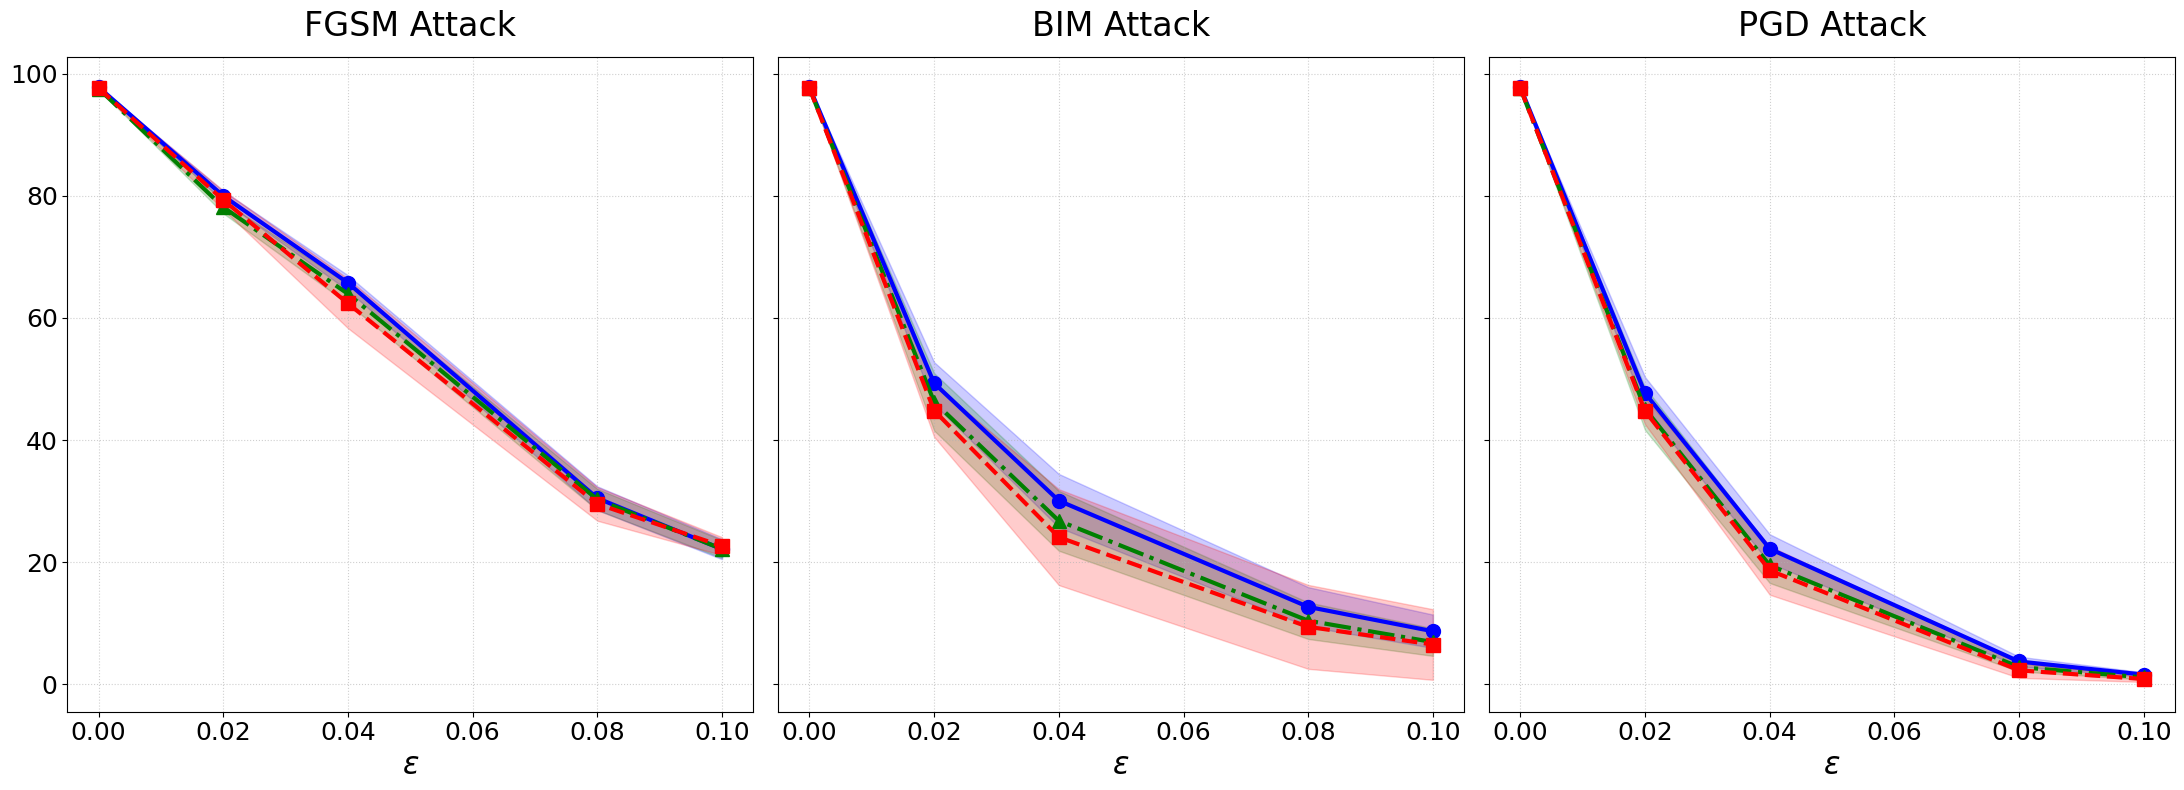

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Epsilon values
epsilons = np.array([0.0, 0.02, 0.04, 0.08, 0.10])

# --- Данные CIFAR-10 ---
fgsm_sur = np.array([97.80, 79.99, 65.75, 30.49, 22.14])
fgsm_sur_std = np.array([0.08, 0.80, 1.24, 1.94, 1.64])
bim_sur = np.array([97.79, 49.32, 30.08, 12.69, 8.70])
bim_sur_std = np.array([0.06, 3.44, 4.38, 3.23, 2.73])
pgd_sur = np.array([97.79, 47.70, 22.21, 3.75, 1.60])
pgd_sur_std = np.array([0.06, 2.63, 2.37, 0.79, 0.37])

fgsm_deep = np.array([97.64, 79.33, 62.38, 29.55, 22.64])
fgsm_deep_std = np.array([0.09, 1.56, 4.05, 2.75, 1.47])
bim_deep = np.array([97.67, 44.84, 24.11, 9.42, 6.53])
bim_deep_std = np.array([0.10, 4.31, 7.85, 6.87, 5.78])
pgd_deep = np.array([97.67, 44.76, 18.67, 2.30, 0.88])
pgd_deep_std = np.array([0.10, 2.17, 3.98, 1.23, 0.48])

fgsm_rand = np.array([97.56, 78.15, 63.94, 30.28, 22.17])
fgsm_rand_std = np.array([0.11, 1.02, 1.59, 1.73, 1.47])
bim_rand = np.array([97.61, 46.27, 26.79, 10.43, 6.93])
bim_rand_std = np.array([0.09, 4.70, 4.90, 2.99, 2.26])
pgd_rand = np.array([97.61, 45.14, 19.49, 2.83, 1.14])
pgd_rand_std = np.array([0.09, 3.48, 2.88, 0.70, 0.34])

# =======================
# Настройки стиля
# =======================
title_fs, label_fs, legend_fs, tick_fs = 24, 22, 18, 18
lw, ms, alpha_fill = 3, 10, 0.2

colors = {"sur": "blue", "de": "red", "rs": "green"}
markers = {"sur": "o", "de": "s", "rs": "^"}
lines = {"sur": "-", "de": "--", "rs": "-."}

# =======================
# Универсальная функция
# =======================
# def plot_attack(ax, eps,
#                 sur, sur_std,
#                 rs, rs_std,
#                 de, de_std,
#                 title, is_first=False):

#     # Surrogate
#     ax.plot(eps, sur, marker=markers["sur"], color=colors["sur"],
#             lw=lw, ms=ms, linestyle=lines["sur"], label='Surrogate Ensemble')
#     ax.fill_between(eps, sur - sur_std, sur + sur_std,
#                     color=colors["sur"], alpha=alpha_fill)

#     # Random Search
#     ax.plot(eps, rs, marker=markers["rs"], color=colors["rs"],
#             lw=lw, ms=ms, linestyle=lines["rs"], label='Random Search')
#     ax.fill_between(eps, rs - rs_std, rs + rs_std,
#                     color=colors["rs"], alpha=alpha_fill)

#     # DeepEns
#     ax.plot(eps, de, marker=markers["de"], color=colors["de"],
#             lw=lw, ms=ms, linestyle=lines["de"], label='DeepEns')
#     ax.fill_between(eps, de - de_std, de + de_std,
#                     color=colors["de"], alpha=alpha_fill)

#     ax.set_title(title, fontsize=title_fs, pad=15)
#     ax.set_xlabel(r'$\varepsilon$', fontsize=label_fs)
#     if is_first:
#         ax.set_ylabel('Accuracy (%)', fontsize=label_fs)
#     ax.tick_params(axis='both', labelsize=tick_fs)
#     ax.grid(True, linestyle=':', alpha=0.6)
#     ax.legend(fontsize=legend_fs, loc='upper right')

# =======================
# Отрисовка
# =======================
fig, axes = plt.subplots(1, 3, figsize=(22, 8), sharey=True)

plot_attack(
    axes[0], epsilons,
    fgsm_sur, fgsm_sur_std,
    fgsm_rand, fgsm_rand_std,
    fgsm_deep, fgsm_deep_std,
    "FGSM Attack"
)

plot_attack(
    axes[1], epsilons,
    bim_sur, bim_sur_std,
    bim_rand, bim_rand_std,
    bim_deep, bim_deep_std,
    "BIM Attack"
)

plot_attack(
    axes[2], epsilons,
    pgd_sur, pgd_sur_std,
    pgd_rand, pgd_rand_std,
    pgd_deep, pgd_deep_std,
    "PGD Attack"
)

plt.tight_layout()
plt.savefig("cifar10_adversarial.pdf", dpi=300, bbox_inches="tight", format="pdf")
plt.show()

CIFAR100

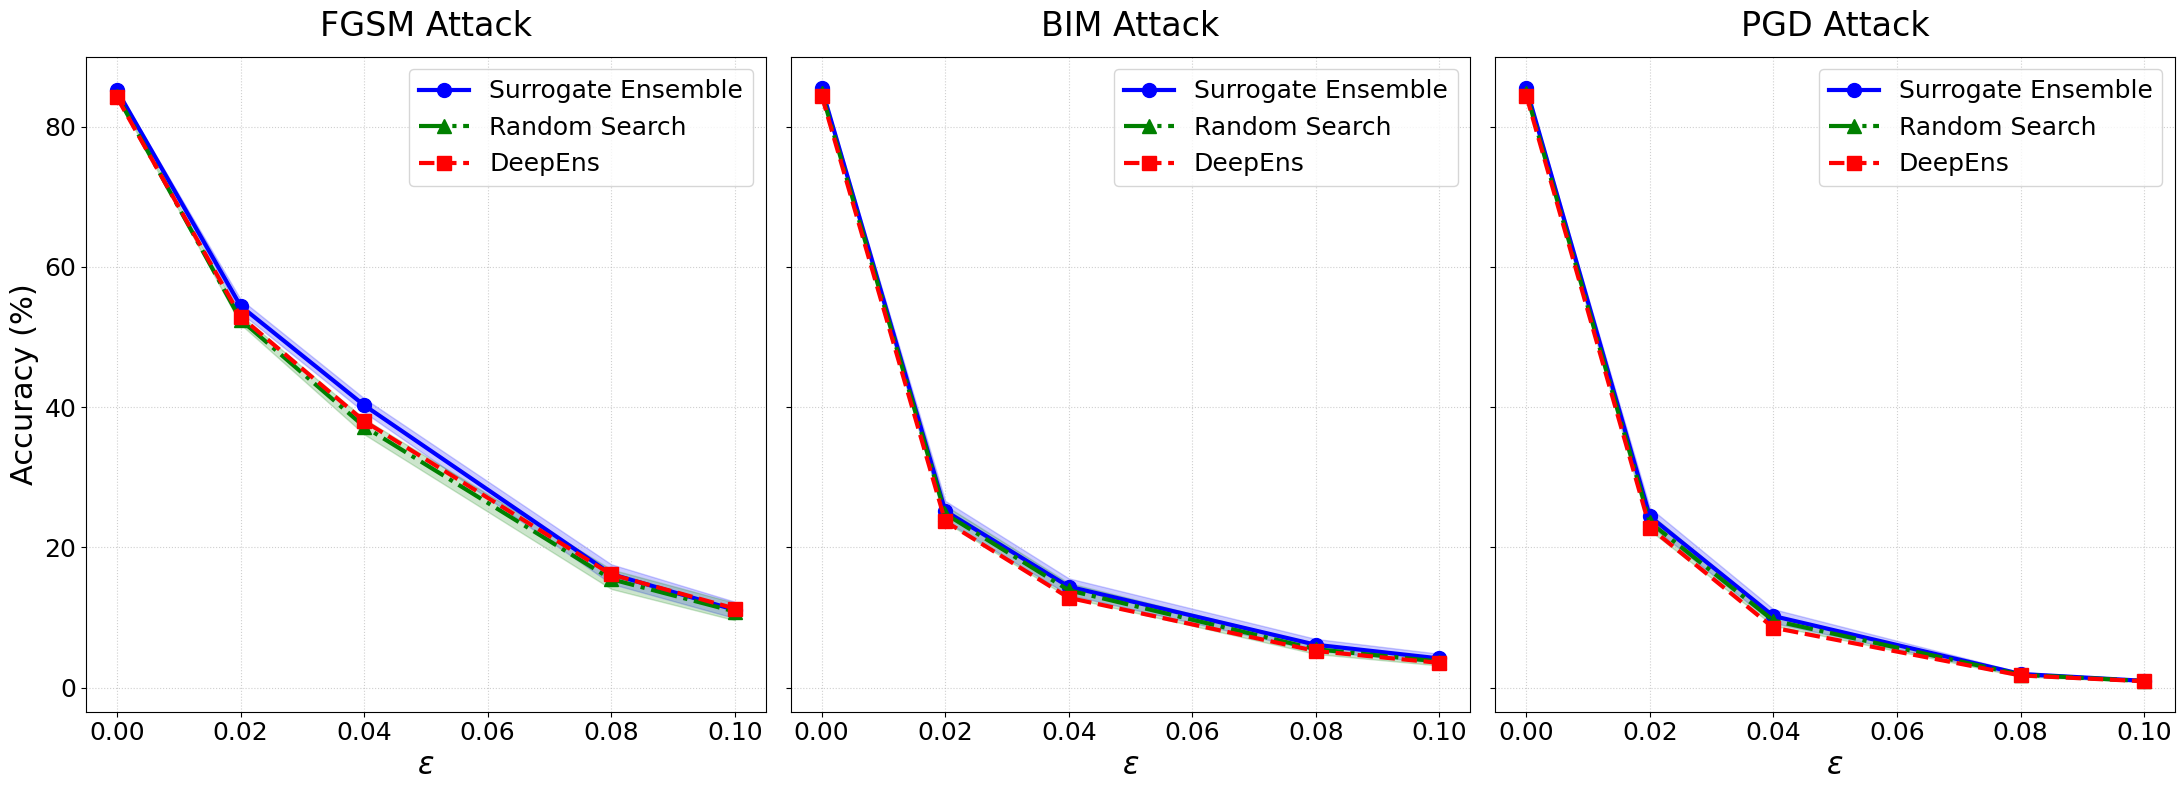

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Epsilon values
epsilons = np.array([0.0, 0.02, 0.04, 0.08, 0.10])

# --- Данные CIFAR-100 ---
# Surrogate ensemble
fgsm_sur = np.array([85.17, 54.43, 40.28, 16.21, 11.10])
fgsm_sur_std = np.array([0.15, 0.96, 0.99, 1.39, 1.17])
bim_sur = np.array([85.50, 25.22, 14.42, 6.13, 4.18])
bim_sur_std = np.array([0.21, 1.43, 1.18, 0.83, 0.67])
pgd_sur = np.array([85.50, 24.43, 10.23, 1.97, 0.99])
pgd_sur_std = np.array([0.21, 1.23, 0.98, 0.23, 0.16])

# DeepEns
fgsm_deep = np.array([84.16, 52.91, 38.02, 16.15, 11.30])
bim_deep = np.array([84.44, 23.74, 12.83, 5.24, 3.55])
pgd_deep = np.array([84.44, 22.83, 8.56, 1.76, 0.93])

# Random Search
fgsm_rand = np.array([84.41, 52.47, 37.25, 15.48, 10.87])
fgsm_rand_std = np.array([0.09, 0.65, 1.11, 1.39, 1.24])
bim_rand = np.array([84.81, 24.81, 13.90, 5.50, 3.74])
bim_rand_std = np.array([0.09, 1.18, 1.03, 0.68, 0.57])
pgd_rand = np.array([84.81, 23.61, 9.58, 1.87, 0.96])
pgd_rand_std = np.array([0.09, 1.19, 0.72, 0.27, 0.11])

# =======================
# Настройки стиля
# =======================
title_fs, label_fs, legend_fs, tick_fs = 24, 22, 18, 18
lw, ms, alpha_fill = 3, 10, 0.2

colors = {"sur": "blue", "de": "red", "rs": "green"}
markers = {"sur": "o", "de": "s", "rs": "^"}
lines = {"sur": "-", "de": "--", "rs": "-."}

# =======================
# Универсальная функция
# =======================
def plot_attack(ax, eps, sur, sur_std, rs, rs_std, de, title, is_first=False):
    # Surrogate
    ax.plot(eps, sur, marker=markers["sur"], color=colors["sur"], 
            lw=lw, ms=ms, linestyle=lines["sur"], label='Surrogate Ensemble')
    ax.fill_between(eps, sur - sur_std, sur + sur_std, color=colors["sur"], alpha=alpha_fill)

    # Random Search
    ax.plot(eps, rs, marker=markers["rs"], color=colors["rs"], 
            lw=lw, ms=ms, linestyle=lines["rs"], label='Random Search')
    ax.fill_between(eps, rs - rs_std, rs + rs_std, color=colors["rs"], alpha=alpha_fill)

    # DeepEns
    ax.plot(eps, de, marker=markers["de"], color=colors["de"], 
            lw=lw, ms=ms, linestyle=lines["de"], label='DeepEns')

    # Оформление
    ax.set_title(title, fontsize=title_fs, pad=15)
    ax.set_xlabel(r'$\varepsilon$', fontsize=label_fs)
    if is_first:
        ax.set_ylabel('Accuracy (%)', fontsize=label_fs)
    ax.tick_params(axis='both', labelsize=tick_fs)
    ax.grid(True, linestyle=':', alpha=0.6)
    
    # Легенда внутри каждого subplot
    ax.legend(fontsize=legend_fs, loc='upper right')

# =======================
# Отрисовка
# =======================
fig, axes = plt.subplots(1, 3, figsize=(22, 8), sharey=True)

plot_attack(axes[0], epsilons, fgsm_sur, fgsm_sur_std, fgsm_rand, fgsm_rand_std, fgsm_deep, "FGSM Attack", is_first=True)
plot_attack(axes[1], epsilons, bim_sur, bim_sur_std, bim_rand, bim_rand_std, bim_deep, "BIM Attack")
plot_attack(axes[2], epsilons, pgd_sur, pgd_sur_std, pgd_rand, pgd_rand_std, pgd_deep, "PGD Attack")

plt.tight_layout()
plt.savefig("cifar100_adversarial.pdf", dpi=300, bbox_inches="tight", format="pdf")
plt.show()

UNITED

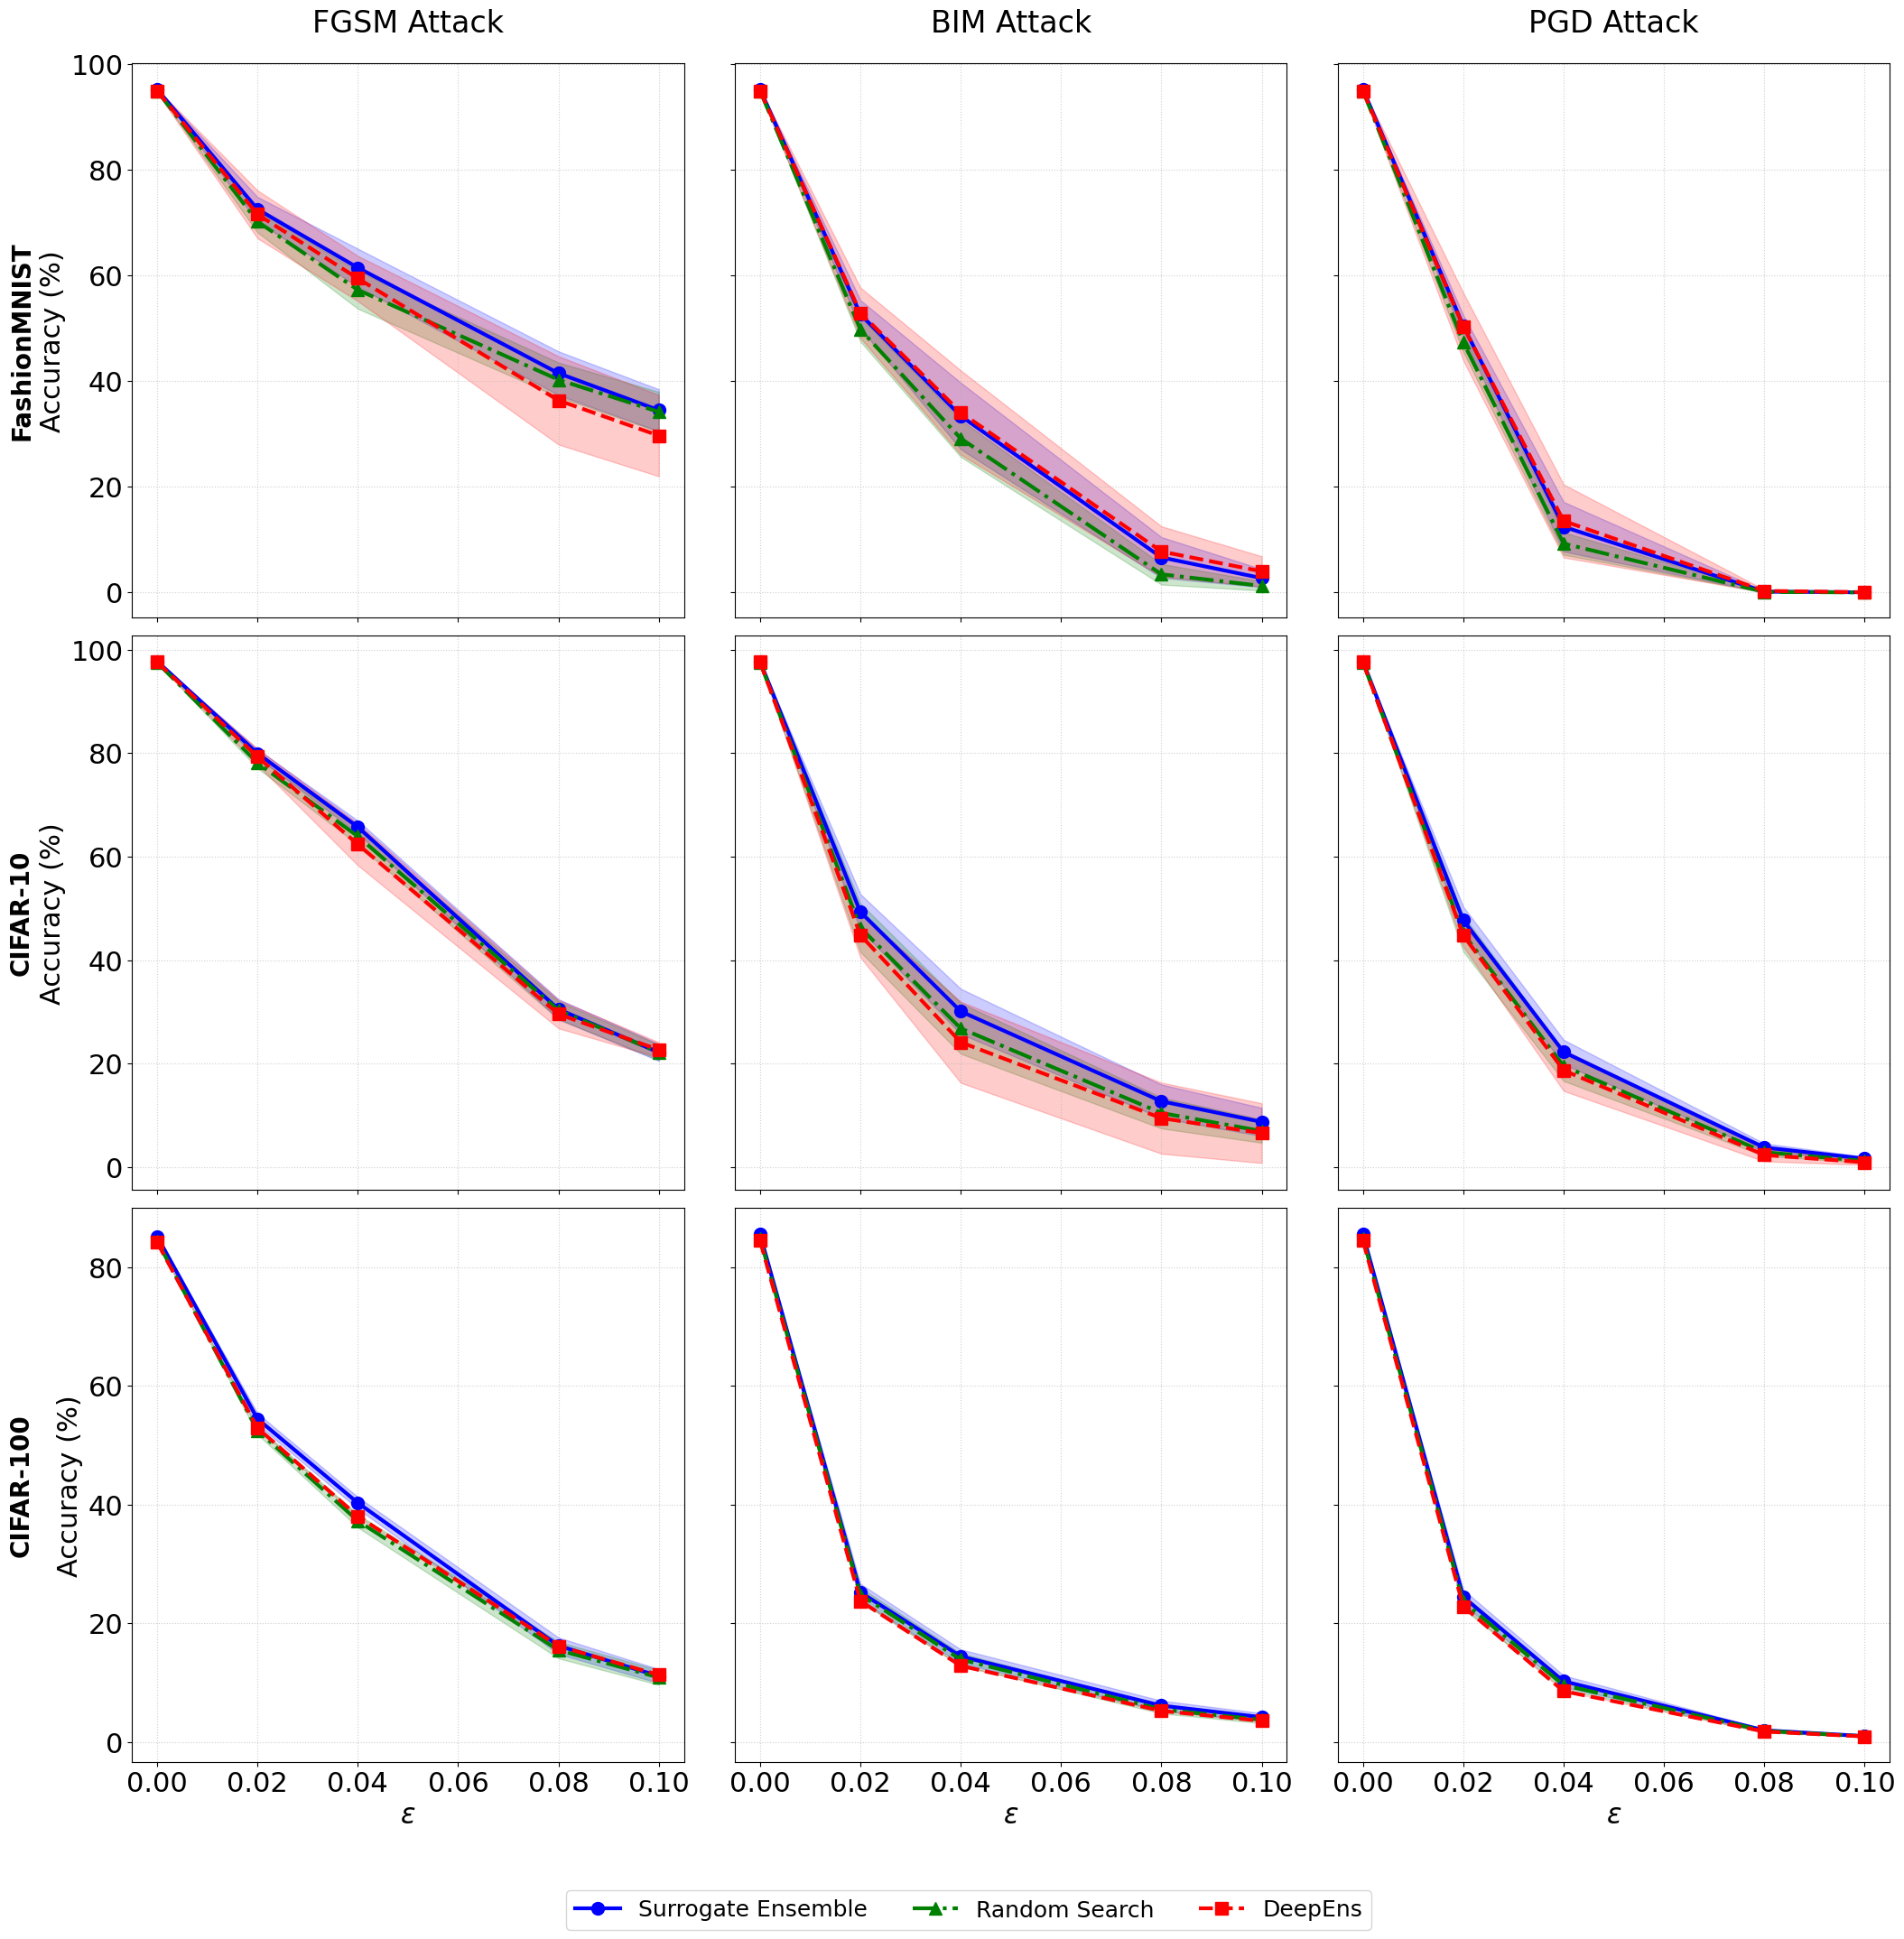

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# [Все данные остаются без изменений — скопированы из предыдущего кода]
eps = np.array([0.00, 0.02, 0.04, 0.08, 0.10])

# FashionMNIST Data
fgsm_sur_mnist = np.array([95.29, 72.59, 61.51, 41.52, 34.52])
fgsm_sur_mnist_std = np.array([0.10, 2.32, 3.60, 4.14, 3.97])
bim_sur_mnist = np.array([95.31, 52.69, 33.43, 6.64, 2.72])
bim_sur_mnist_std = np.array([0.12, 2.68, 6.31, 3.85, 1.71])
pgd_sur_mnist = np.array([95.31, 50.50, 12.45, 0.17, 0.03])
pgd_sur_mnist_std = np.array([0.12, 2.05, 4.70, 0.14, 0.04])

fgsm_rs_mnist = np.array([95.01, 70.25, 57.31, 40.29, 34.20])
fgsm_rs_mnist_std = np.array([0.19, 2.05, 3.57, 3.26, 3.79])
bim_rs_mnist = np.array([95.02, 49.80, 29.17, 3.44, 1.25])
bim_rs_mnist_std = np.array([0.18, 2.28, 3.50, 1.94, 0.89])
pgd_rs_mnist = np.array([95.02, 47.36, 9.26, 0.11, 0.01])
pgd_rs_mnist_std = np.array([0.18, 1.79, 2.12, 0.10, 0.01])

fgsm_de_mnist = np.array([95.02, 71.62, 59.47, 36.38, 29.70])
fgsm_de_mnist_std = np.array([0.35, 4.54, 4.28, 8.36, 7.70])
bim_de_mnist = np.array([95.02, 52.96, 34.09, 7.76, 4.00])
bim_de_mnist_std = np.array([0.37, 4.78, 7.98, 4.77, 2.86])
pgd_de_mnist = np.array([95.02, 50.35, 13.55, 0.30, 0.05])
pgd_de_mnist_std = np.array([0.37, 6.42, 6.92, 0.25, 0.04])

# CIFAR-10 Data
fgsm_sur_c10 = np.array([97.80, 79.99, 65.75, 30.49, 22.14])
fgsm_sur_c10_std = np.array([0.08, 0.80, 1.24, 1.94, 1.64])
bim_sur_c10 = np.array([97.79, 49.32, 30.08, 12.69, 8.70])
bim_sur_c10_std = np.array([0.06, 3.44, 4.38, 3.23, 2.73])
pgd_sur_c10 = np.array([97.79, 47.70, 22.21, 3.75, 1.60])
pgd_sur_c10_std = np.array([0.06, 2.63, 2.37, 0.79, 0.37])

fgsm_deep_c10 = np.array([97.64, 79.33, 62.38, 29.55, 22.64])
fgsm_deep_c10_std = np.array([0.09, 1.56, 4.05, 2.75, 1.47])
bim_deep_c10 = np.array([97.67, 44.84, 24.11, 9.42, 6.53])
bim_deep_c10_std = np.array([0.10, 4.31, 7.85, 6.87, 5.78])
pgd_deep_c10 = np.array([97.67, 44.76, 18.67, 2.30, 0.88])
pgd_deep_c10_std = np.array([0.10, 2.17, 3.98, 1.23, 0.48])

fgsm_rand_c10 = np.array([97.56, 78.15, 63.94, 30.28, 22.17])
fgsm_rand_c10_std = np.array([0.11, 1.02, 1.59, 1.73, 1.47])
bim_rand_c10 = np.array([97.61, 46.27, 26.79, 10.43, 6.93])
bim_rand_c10_std = np.array([0.09, 4.70, 4.90, 2.99, 2.26])
pgd_rand_c10 = np.array([97.61, 45.14, 19.49, 2.83, 1.14])
pgd_rand_c10_std = np.array([0.09, 3.48, 2.88, 0.70, 0.34])

# CIFAR-100 Data
fgsm_sur_c100 = np.array([85.17, 54.43, 40.28, 16.21, 11.10])
fgsm_sur_c100_std = np.array([0.15, 0.96, 0.99, 1.39, 1.17])
bim_sur_c100 = np.array([85.50, 25.22, 14.42, 6.13, 4.18])
bim_sur_c100_std = np.array([0.21, 1.43, 1.18, 0.83, 0.67])
pgd_sur_c100 = np.array([85.50, 24.43, 10.23, 1.97, 0.99])
pgd_sur_c100_std = np.array([0.21, 1.23, 0.98, 0.23, 0.16])

fgsm_deep_c100 = np.array([84.16, 52.91, 38.02, 16.15, 11.30])
bim_deep_c100 = np.array([84.44, 23.74, 12.83, 5.24, 3.55])
pgd_deep_c100 = np.array([84.44, 22.83, 8.56, 1.76, 0.93])
fgsm_deep_c100_std = np.zeros(5)
bim_deep_c100_std = np.zeros(5)
pgd_deep_c100_std = np.zeros(5)

fgsm_rand_c100 = np.array([84.41, 52.47, 37.25, 15.48, 10.87])
fgsm_rand_c100_std = np.array([0.09, 0.65, 1.11, 1.39, 1.24])
bim_rand_c100 = np.array([84.81, 24.81, 13.90, 5.50, 3.74])
bim_rand_c100_std = np.array([0.09, 1.18, 1.03, 0.68, 0.57])
pgd_rand_c100 = np.array([84.81, 23.61, 9.58, 1.87, 0.96])
pgd_rand_c100_std = np.array([0.09, 1.19, 0.72, 0.27, 0.11])

# Style Settings
title_fs = 24
label_fs = 22
legend_fs = 18
tick_fs = 22
dataset_label_fs = 20

lw = 3
ms = 10
alpha_fill = 0.20

colors = {"sur": "blue", "rs": "green", "de": "red"}
markers = {"sur": "o", "rs": "^", "de": "s"}
linestyles = {"sur": "-", "rs": "-.", "de": "--"}

def plot_attack_cell(ax, eps, sur, sur_std, rs, rs_std, de, de_std):
    ax.plot(eps, sur, marker=markers["sur"], color=colors["sur"],
            lw=lw, ms=ms, linestyle=linestyles["sur"], label="Surrogate Ensemble")
    ax.fill_between(eps, sur - sur_std, sur + sur_std,
                    color=colors["sur"], alpha=alpha_fill)
    ax.plot(eps, rs, marker=markers["rs"], color=colors["rs"],
            lw=lw, ms=ms, linestyle=linestyles["rs"], label="Random Search")
    ax.fill_between(eps, rs - rs_std, rs + rs_std,
                    color=colors["rs"], alpha=alpha_fill)
    ax.plot(eps, de, marker=markers["de"], color=colors["de"],
            lw=lw, ms=ms, linestyle=linestyles["de"], label="DeepEns")
    ax.fill_between(eps, de - de_std, de + de_std,
                    color=colors["de"], alpha=alpha_fill)
    ax.tick_params(axis="both", labelsize=tick_fs)
    ax.grid(True, linestyle=':', alpha=0.6)

fig, axes = plt.subplots(3, 3, figsize=(22, 22), sharex=True, sharey='row')

datasets_rows = [
    {
        "name": "FashionMNIST",
        "fgsm": (fgsm_sur_mnist, fgsm_sur_mnist_std, fgsm_rs_mnist, fgsm_rs_mnist_std, fgsm_de_mnist, fgsm_de_mnist_std),
        "bim": (bim_sur_mnist, bim_sur_mnist_std, bim_rs_mnist, bim_rs_mnist_std, bim_de_mnist, bim_de_mnist_std),
        "pgd": (pgd_sur_mnist, pgd_sur_mnist_std, pgd_rs_mnist, pgd_rs_mnist_std, pgd_de_mnist, pgd_de_mnist_std),
    },
    {
        "name": "CIFAR-10",
        "fgsm": (fgsm_sur_c10, fgsm_sur_c10_std, fgsm_rand_c10, fgsm_rand_c10_std, fgsm_deep_c10, fgsm_deep_c10_std),
        "bim": (bim_sur_c10, bim_sur_c10_std, bim_rand_c10, bim_rand_c10_std, bim_deep_c10, bim_deep_c10_std),
        "pgd": (pgd_sur_c10, pgd_sur_c10_std, pgd_rand_c10, pgd_rand_c10_std, pgd_deep_c10, pgd_deep_c10_std),
    },
    {
        "name": "CIFAR-100",
        "fgsm": (fgsm_sur_c100, fgsm_sur_c100_std, fgsm_rand_c100, fgsm_rand_c100_std, fgsm_deep_c100, fgsm_deep_c100_std),
        "bim": (bim_sur_c100, bim_sur_c100_std, bim_rand_c100, bim_rand_c100_std, bim_deep_c100, bim_deep_c100_std),
        "pgd": (pgd_sur_c100, pgd_sur_c100_std, pgd_rand_c100, pgd_rand_c100_std, pgd_deep_c100, pgd_deep_c100_std),
    }
]

attack_cols = ["fgsm", "bim", "pgd"]
attack_titles = ["FGSM Attack", "BIM Attack", "PGD Attack"]

for row_idx, dataset in enumerate(datasets_rows):
    for col_idx, attack_key in enumerate(attack_cols):
        ax = axes[row_idx, col_idx]
        data = dataset[attack_key]
        
        plot_attack_cell(ax, eps, *data)
        
        # Заголовки с увеличенным отступом (pad=25)
        if row_idx == 0:
            ax.set_title(attack_titles[col_idx], fontsize=title_fs, pad=25)
        
        if col_idx == 0:
            ax.set_ylabel("Accuracy (%)", fontsize=label_fs)
            ax.text(
                -0.2, 0.5, dataset["name"],  # Было -0.22, стало -0.18
                transform=ax.transAxes,
                fontsize=dataset_label_fs,
                rotation=90,
                va="center",
                ha="center",
                fontweight="bold"
            )

        if row_idx == 2:
            ax.set_xlabel(r"$\epsilon$", fontsize=label_fs)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, fontsize=legend_fs, 
           bbox_to_anchor=(0.5, -0.02), frameon=True)

# Немного увеличил отступы по краям
plt.tight_layout(rect=[0.02, 0.03, 0.98, 0.96])
plt.savefig("adversarial_comparison_3x3.pdf", dpi=300, bbox_inches="tight", format="pdf")
plt.show()